<a href="https://colab.research.google.com/github/cahyoadi88/Script/blob/main/Copy_of_POWER_ANALYSIS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Packages imports
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.stats.api as sms
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

%matplotlib inline

function references


1.   NormalIndPower().solve_power: https://tedboy.github.io/statsmodels_doc/generated/generated/statsmodels.stats.api.NormalIndPower.solve_power.html?highlight=normalindpower
2.   List item



In [ ]:
# Calculating effect size based on our expected rates

#effect size for a test comparing two proportions
#awalnya cr 13%, ingin peningkatan 2%
effect_size = sms.proportion_effectsize(0.13, 0.15) 

#solve for any one parameter of the power of a two sample z-test
required_n = sms.NormalIndPower().solve_power(
    effect_size, 
    power=0.8, 
    alpha=0.05,
    )                                                  # Calculating sample size needed
print(required_n)
required_n = ceil(required_n)                        # Rounding up to next whole number                          



4719.4740575998185


Having set the power parameter to 0.8 in practice means that if there exists an actual difference in conversion rate between our designs, assuming the difference is the one we estimated (13% vs. 15%), we have about 80% chance to detect it as statistically significant in our test with the sample size we calculated.

In [ ]:
df = pd.read_csv('ab_data.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [ ]:
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


In [ ]:
# To make sure all the control group are seeing the old page and viceversa
df1 = df.loc[(df['group'] == "control") & (df['landing_page'] == "old_page")]
df2 = df.loc[(df['group'] == "treatment") & (df['landing_page'] == "new_page")]
df = pd.concat([df1, df2], axis=0)
pd.crosstab(df['group'], df['landing_page'])

landing_page,new_page,old_page
group,,
control,0,145274
treatment,145311,0


In [ ]:
control_sample = df[df['group'] == 'control'].sample(n=required_n, random_state=44)
treatment_sample = df[df['group'] == 'treatment'].sample(n=required_n, random_state=44)

ab_test = pd.concat([control_sample, treatment_sample], axis=0)
ab_test.reset_index(drop=True, inplace=True)
ab_test

,user_id,timestamp,group,landing_page,converted
0,724351,2017-01-23 12:17:19.675749,control,old_page,0
1,678977,2017-01-06 17:03:43.327553,control,old_page,0
2,700376,2017-01-10 08:31:51.749920,control,old_page,0
3,827873,2017-01-05 08:33:49.583219,control,old_page,1
4,631718,2017-01-04 23:50:00.687053,control,old_page,0
...,...,...,...,...,...
9435,726219,2017-01-15 21:26:08.501929,treatment,new_page,0
9436,749949,2017-01-16 16:30:30.535113,treatment,new_page,0
9437,762385,2017-01-15 23:36:24.027456,treatment,new_page,0
9438,799359,2017-01-08 06:10:12.135902,treatment,new_page,0


In [ ]:
pd.crosstab(ab_test['group'], ab_test['landing_page'])

landing_page,new_page,old_page
group,,
control,0,4720
treatment,4720,0


In [ ]:
old_conv = ab_test[ab_test['group'] == 'control'].converted.sum()/4720
new_conv = ab_test[ab_test['group'] == 'treatment'].converted.sum()/4720
print("conv rate old page ", old_conv)
print("conv rate new page ", new_conv)

conv rate old page  0.12436440677966101
conv rate new page  0.1260593220338983


<ipython-input-25-21982b4d6101>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(x=ab_test['group'], y=ab_test['converted'], ci=False)


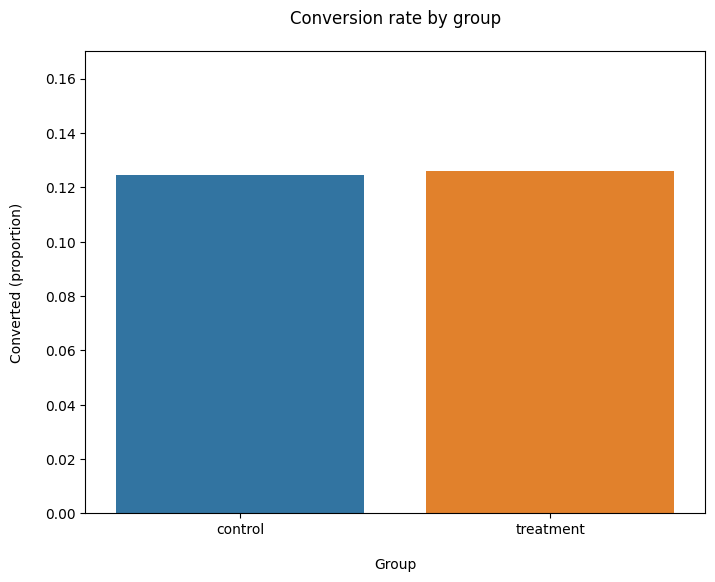

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(x=ab_test['group'], y=ab_test['converted'], ci=False)

plt.ylim(0, 0.17)
plt.title('Conversion rate by group', pad=20)
plt.xlabel('Group', labelpad=15)
plt.ylabel('Converted (proportion)', labelpad=15);

# testing 

In A/B testing, a z-test is a statistical hypothesis test used to determine whether there is a significant difference between two proportions or means.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
control_results = ab_test[ab_test['group'] == 'control']['converted']
treatment_results = ab_test[ab_test['group'] == 'treatment']['converted']
n_con = control_results.count()
n_treat = treatment_results.count()
successes = [control_results.sum(), treatment_results.sum()]
nobs = [n_con, n_treat]

z_stat, pval = proportions_ztest(successes, nobs=nobs)

print(f'z statistic: {z_stat:.2f}')
print(f'p-value: {pval:.3f}')

z statistic: -0.25
p-value: 0.804


our new design did not perform significantly different from the old design. 

In [ ]:
successes

[587, 595]

In [ ]:
z_stat, pval = proportions_ztest([587, 680], nobs=[4720, 4720])

print(f'z statistic: {z_stat:.2f}')
print(f'p-value: {pval:.3f}')

z statistic: -2.81
p-value: 0.005
